Summary of Code:
This code visualizes property assessment data over multiple years (2016 to 2024) using heatmaps to show trends in overall condition and building classification by ZIP code. Each sheet in an Excel file represents data for a specific year, which is merged into a single DataFrame for analysis.

Data Loading and Preparation: The code reads multiple sheets from an Excel file, where each sheet corresponds to a different year. It adds a "YEAR" column to each sheet’s data and merges them into a single DataFrame, all_data. The code maps categorical values for overall condition and building classification to numeric values for visualization purposes.

Mapping and Visualizing Conditions and Classifications:

A dictionary mapping assigns numeric values to labels in overall_cond_label and building_classification columns, enabling a gradient color scheme for better readability in heatmaps.
The color schemes are customized, with overall_cond_label mapped from red to green (indicating poor to excellent conditions) and building_classification mapped similarly from red to green (indicating old to new buildings).
Heatmap Visualization for Condition:

The data is pivoted so that each ZIP code is shown on the y-axis, with years on the x-axis, and condition values filling the heatmap cells. The custom legend shows condition labels (Unsound to Very Good) with corresponding colors.
Heatmap Visualization for Building Classification:

A second heatmap shows building classification data over time with a similar structure, where red represents older buildings and green represents newer ones. Custom legends enhance clarity by explaining the color-to-label mappings for building classifications (Old to New).

This visualization provides a clear representation of housing condition trends and building classifications across ZIP codes and years, facilitating insights into property conditions over time.

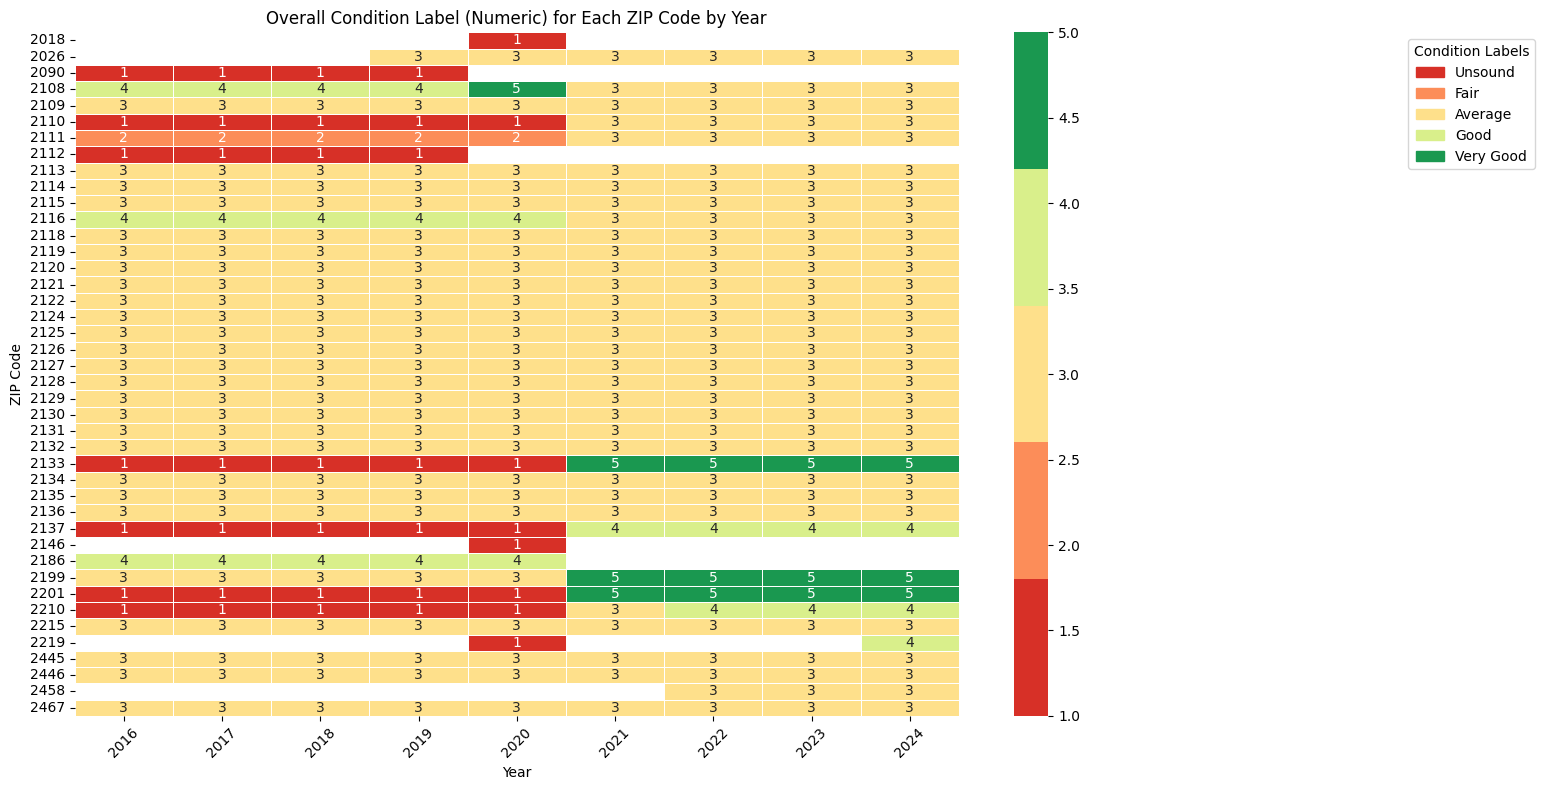

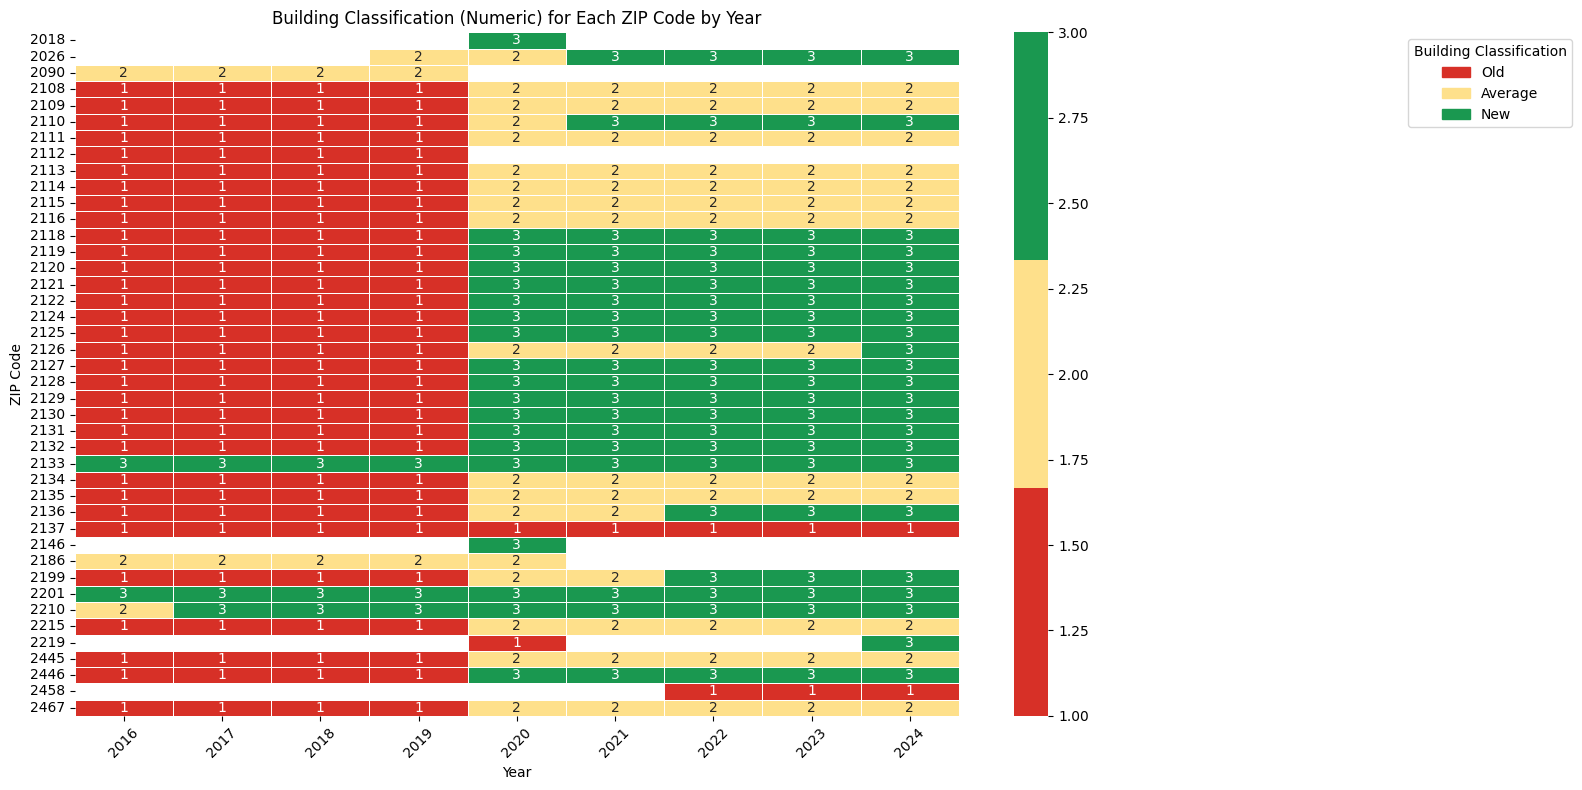

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# Define the file path for the Excel file
file_path = r'C:\Users\sul19\Desktop\701 Project\Property Assessment Datasets\Final Excels\Graphs.xlsx'

# Load the Excel file
excel_file = pd.ExcelFile(file_path)

# Initialize an empty DataFrame to store the combined data
all_data = pd.DataFrame()

# Iterate through each sheet in the Excel file
for sheet in excel_file.sheet_names:
    # Read the sheet into a DataFrame
    sheet_data = excel_file.parse(sheet)
    # Add a 'YEAR' column to the DataFrame based on the sheet name
    sheet_data['YEAR'] = int(sheet)  # Assuming sheet names are the years (2016, 2017, etc.)
    # Append the data to the all_data DataFrame
    all_data = pd.concat([all_data, sheet_data], ignore_index=True)

# Define a dictionary to map overall condition labels to numeric values
condition_mapping = {
    'Unsound': 1,
    'Fair': 2,
    'Average': 3,
    'Good': 4,
    'Very Good': 5
}

# Replace the overall_cond_label with numeric values using the mapping
all_data['overall_cond_label_numeric'] = all_data['overall_cond_label'].map(condition_mapping)

# Define a dictionary to map building classifications to numeric values (without 'Unknown')
building_class_mapping = {
    'Old': 1,
    'Average': 2,
    'New': 3
}

# Replace the building_classification with numeric values using the mapping
all_data['building_classification_numeric'] = all_data['building_classification'].map(building_class_mapping)

# Custom color map for Overall Condition (red for Unsound, green for Very Good)
colors_condition = ['#d73027', '#fc8d59', '#fee08b', '#d9ef8b', '#1a9850']  # Red to green
cmap_condition = ListedColormap(colors_condition)

### Heatmap for Overall Condition Label ###
# Pivot the data so that ZIP_CODE is the index, YEAR is the columns, and numeric condition label is the values
pivot_data_condition = all_data.pivot_table(index='ZIP_CODE', columns='YEAR', values='overall_cond_label_numeric', aggfunc='first')

# Use a heatmap to visualize the numeric condition label for each ZIP_CODE by year
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_data_condition, annot=True, cmap=cmap_condition, cbar=True, linewidths=0.5)

# Customizing the plot
plt.title('Overall Condition Label (Numeric) for Each ZIP Code by Year')
plt.xlabel('Year')
plt.ylabel('ZIP Code')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

# Create a custom legend for Overall Condition Label
condition_labels = ['Unsound', 'Fair', 'Average', 'Good', 'Very Good']
legend_colors_condition = colors_condition

# Create legend patches for Overall Condition
patches_condition = [mpatches.Patch(color=color, label=label) for color, label in zip(legend_colors_condition, condition_labels)]

# Add legend for Overall Condition and move it further to the right
plt.legend(handles=patches_condition, title='Condition Labels', bbox_to_anchor=(1.5, 1), loc='upper left')

# Display the first heatmap
plt.show()

### Custom color map for Building Classification (red for Old, green for New) ###
colors_building = ['#d73027', '#fee08b', '#1a9850']  # Red to green for Old, Average, New
cmap_building = ListedColormap(colors_building)

### Heatmap for Building Classification ###
# Pivot the data so that ZIP_CODE is the index, YEAR is the columns, and numeric building classification is the values
pivot_data_building = all_data.pivot_table(index='ZIP_CODE', columns='YEAR', values='building_classification_numeric', aggfunc='first')

# Use a heatmap to visualize the numeric building classification for each ZIP_CODE by year
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_data_building, annot=True, cmap=cmap_building, cbar=True, linewidths=0.5)

# Customizing the plot
plt.title('Building Classification (Numeric) for Each ZIP Code by Year')
plt.xlabel('Year')
plt.ylabel('ZIP Code')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

# Create a custom legend for Building Classification
building_labels = ['Old', 'Average', 'New']
legend_colors_building = colors_building

# Create legend patches for Building Classification
patches_building = [mpatches.Patch(color=color, label=label) for color, label in zip(legend_colors_building, building_labels)]

# Add legend for Building Classification and move it further to the right
plt.legend(handles=patches_building, title='Building Classification', bbox_to_anchor=(1.5, 1), loc='upper left')

# Display the second heatmap
plt.show()
